# BTCUSDT Data Exploration

Explore Bybit spot BTCUSDT hourly candles for **2025-10-01 00:00 UTC through 2026-10-01 00:00 UTC (exclusive)**. Only completed candles are included. This notebook uses public market data and needs no API keys.

Reusable loading code belongs in `src/` so notebooks, future backtests, and analytics can use the same normalization and validation. The exchange adapter handles Bybit HTTP details; the data module handles the dataset. No trading functionality is implemented.

## 1. Imports

The project uses a `src/` layout. Until package installation is configured, add the project’s `src` directory to Python’s import path. This works when the notebook starts in either the project root or `notebooks/`.

In [1]:
from pathlib import Path
import sys

%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = next(
    folder for folder in [Path.cwd(), *Path.cwd().parents]
    if (folder / "src" / "trading_lab").is_dir()
)
source_directory = str(PROJECT_ROOT / "src")
if source_directory not in sys.path:
    sys.path.insert(0, source_directory)

from trading_lab.data.market_data import (
    download_ohlcv,
    invalid_ohlc_mask,
    load_ohlcv_csv,
    save_ohlcv,
    validate_ohlcv,
)

Matplotlib is building the font cache; this may take a moment.


/Users/romankondratenko/trading-lab/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 2. Load Historical Data

Load the local snapshot if it exists. Otherwise call the reusable loader and save it once. The fixed period makes repeated research comparable; using newly downloaded data for every future backtest could change its inputs.

Bybit returns up to 1,000 candles per page, newest first. The loader requests earlier pages by setting each new `end` to one millisecond before the previous page’s oldest timestamp. It turns the JSON candle arrays into a pandas DataFrame, selects the six OHLCV fields, converts prices and volume to numbers, and converts millisecond timestamps to UTC datetimes. UTC avoids ambiguous local times, and chronological sorting makes gaps and time-based analysis easier to see.

Identical duplicate candles trigger a warning and are deduplicated. Conflicting duplicates, invalid values, missing candles, and unexpected responses raise clear errors. Existing raw files are never overwritten.

In [2]:
START = "2025-10-01T00:00:00Z"
END = "2026-10-01T00:00:00Z"  # Exclusive: the last candle opens one hour earlier.
CSV_PATH = PROJECT_ROOT / "data" / "raw" / "BTCUSDT_1h.csv"

if CSV_PATH.exists():
    df = load_ohlcv_csv(CSV_PATH, interval="60", start=START, end=END)
    print("Loaded local snapshot:", CSV_PATH)
else:
    df = download_ohlcv(
        start=START, end=END, symbol="BTCUSDT", category="spot", interval="60"
    )
    save_ohlcv(df, CSV_PATH)
    print("Downloaded and saved:", CSV_PATH)
    print("API pages:", df.attrs["pages_downloaded"])
    print("Identical duplicates removed:", df.attrs["duplicate_rows_removed"])

Loaded local snapshot: /Users/romankondratenko/trading-lab/Trading Lab/data/raw/BTCUSDT_1h.csv


## 3. Inspect Dataset

`head()` and `tail()` show the beginning and end. `shape` gives (rows, columns); `info()` describes column types and non-missing counts.

In [3]:
df.head()

,timestamp,open,high,low,close,volume
0,2025-10-01 00:00:00+00:00,114051.1,114300.3,113962.3,114241.0,256.712737
1,2025-10-01 01:00:00+00:00,114241.0,114550.0,114142.2,114549.4,240.479371
2,2025-10-01 02:00:00+00:00,114549.4,114551.9,114252.4,114275.5,219.500905
3,2025-10-01 03:00:00+00:00,114275.5,114533.5,114100.1,114178.1,296.903591
4,2025-10-01 04:00:00+00:00,114178.1,114710.2,114140.7,114291.0,280.776000


In [4]:
df.tail()

,timestamp,open,high,low,close,volume
8755,2026-09-30 19:00:00+00:00,83944.6,83960.7,83491.2,83595.4,260.379820
8756,2026-09-30 20:00:00+00:00,83595.4,83779.4,83522.7,83670.5,139.220277
8757,2026-09-30 21:00:00+00:00,83670.5,83820.2,83670.5,83758.6,91.674001
8758,2026-09-30 22:00:00+00:00,83758.6,83840.8,83575.1,83683.2,81.231509
8759,2026-09-30 23:00:00+00:00,83683.2,83836.7,83524.3,83616.2,163.752491


In [5]:
df.shape

(8760, 6)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype              
---  ------     --------------  -----              
 0   timestamp  8760 non-null   datetime64[ns, UTC]
 1   open       8760 non-null   float64            
 2   high       8760 non-null   float64            
 3   low        8760 non-null   float64            
 4   close      8760 non-null   float64            
 5   volume     8760 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(5)
memory usage: 410.8 KB


In [7]:
df.dtypes

timestamp    datetime64[ns, UTC]
open                     float64
high                     float64
low                      float64
close                    float64
volume                   float64
dtype: object

## 4. Data Quality Checks

Look for missing values, duplicated timestamps, incorrect time order, inconsistent candle prices, and missing hourly candles. `high` must be at least open, close, and low; `low` must be at most open, close, and high. Prices must be positive and volume cannot be negative (zero volume is allowed).

The reusable loader validates before returning or saving data, so invalid raw data cannot silently reach the normal analysis path. The following examples make those checks visible for learning. If investigating a problematic DataFrame, inspect the displayed rows; do not silently remove them or edit the raw file.

In [8]:
df.isna().sum()

timestamp    0
open         0
high         0
low          0
close        0
volume       0
dtype: int64

In [9]:
duplicate_rows = df[df["timestamp"].duplicated(keep=False)]
print("Duplicate timestamps:", df["timestamp"].duplicated().sum())
print("Chronological order:", df["timestamp"].is_monotonic_increasing)
display(duplicate_rows)

invalid_rows = df.loc[invalid_ohlc_mask(df)]
print("Invalid OHLC/volume rows:", len(invalid_rows))
display(invalid_rows)

expected_hours = pd.date_range(START, END, freq="h", inclusive="left")
missing_hours = expected_hours.difference(pd.DatetimeIndex(df["timestamp"]))
print("Missing hourly candles:", len(missing_hours))
display(missing_hours[:10])

quality = validate_ohlcv(df, interval="60", start=START, end=END)
quality

Duplicate timestamps: 0
Chronological order: True


,timestamp,open,high,low,close,volume


Invalid OHLC/volume rows: 0


,timestamp,open,high,low,close,volume


Missing hourly candles: 0


DatetimeIndex([], dtype='datetime64[ns, UTC]', freq='h')

{'rows': 8760,
 'earliest_timestamp': Timestamp('2025-10-01 00:00:00+0000', tz='UTC'),
 'latest_timestamp': Timestamp('2026-09-30 23:00:00+0000', tz='UTC'),
 'missing_values': {'timestamp': 0,
  'open': 0,
  'high': 0,
  'low': 0,
  'close': 0,
  'volume': 0},
 'duplicate_timestamps': 0,
 'chronological': True,
 'invalid_ohlc_rows': 0,
 'missing_candles': 0}

## 5. Summary Statistics

`describe()` summarizes the numeric columns: counts, averages, standard deviations, quartiles, and ranges. These are descriptive summaries of candles, not strategy performance metrics.

In [10]:
df.describe()

,open,high,low,close,volume
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,79903.065103,80152.127727,79640.502918,79899.590799,399.856328
std,15288.026554,15328.033920,15236.367805,15283.722963,339.882760
min,58301.100000,58623.500000,57802.200000,58301.100000,16.659988
25%,66937.125000,67182.550000,66716.425000,66937.125000,191.253882
50%,77331.400000,77509.750000,77154.450000,77331.400000,303.670497
75%,89123.725000,89394.950000,88810.100000,89116.125000,499.002103
max,126012.400000,126195.500000,125236.200000,126012.400000,7196.330230


## 6. Price Visualization

Plot the hourly closing price in USDT. A candle’s timestamp marks its opening time.

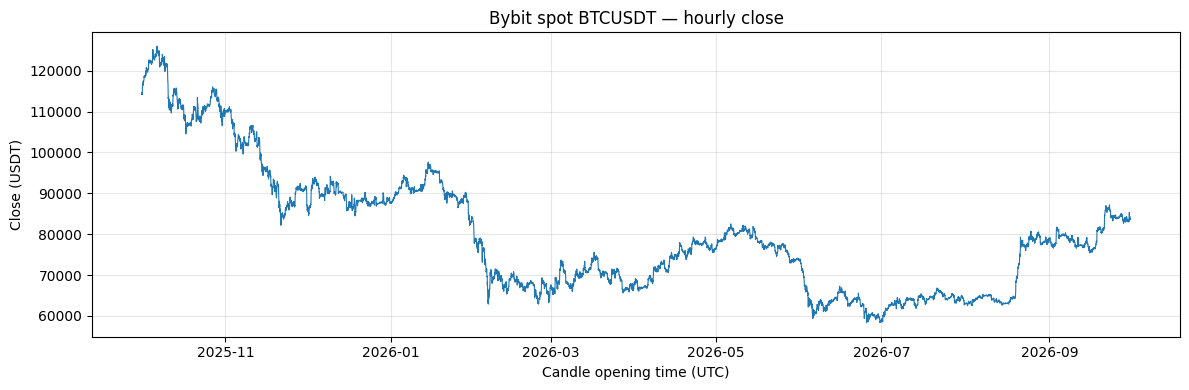

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["timestamp"], df["close"], linewidth=0.8)
ax.set(title="Bybit spot BTCUSDT — hourly close", xlabel="Candle opening time (UTC)", ylabel="Close (USDT)")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 7. Volume Visualization

Plot hourly traded BTC volume. Large spikes are observations to investigate, not trading signals.

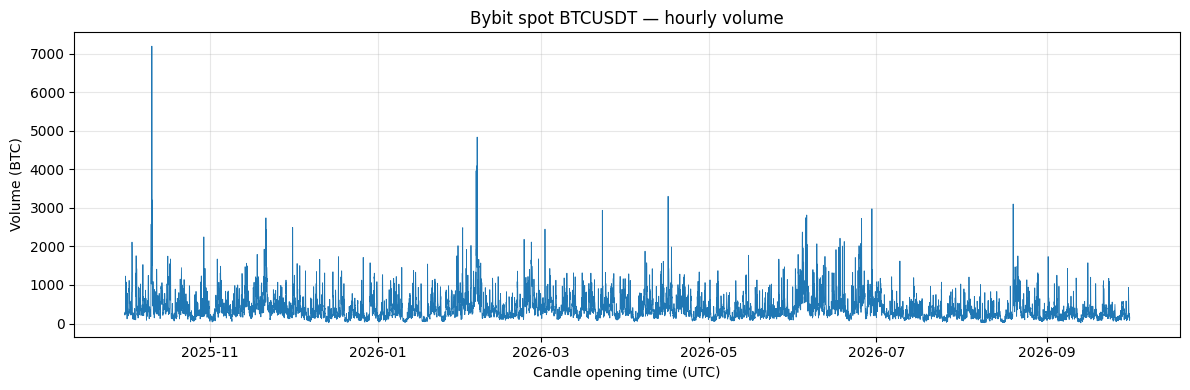

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["timestamp"], df["volume"], linewidth=0.6)
ax.set(title="Bybit spot BTCUSDT — hourly volume", xlabel="Candle opening time (UTC)", ylabel="Volume (BTC)")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 8. Observations

Record findings after inspecting the outputs:

- Does the dataset cover every expected hour? What are its first and last timestamps?
- Are there missing values, duplicates, or invalid candles?
- Which periods show noticeable price changes or unusual volume?
- Are any apparent anomalies supported by the underlying rows and source data?

Keep the raw snapshot limited to `timestamp`, `open`, `high`, `low`, `close`, and `volume`. Indicators, returns, volatility, and signals are transformations for later stages; adding them to raw data would mix observations with research choices. Store future transformed copies under `data/processed/`.

Summary statistics and plots describe this dataset. They do not establish that any trading strategy is profitable.